In [51]:
# cleaning #

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Banking_Churn_Prediction_Dataset.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15756560,Smith,535,Germany,Male,36,8,12522.885770,4,1,0,111873.839057,0
1,2,15781469,Johnson,675,France,Female,23,1,34322.606949,4,0,0,107262.028986,0
2,3,15766534,Williams,786,Germany,Male,23,3,66067.728832,3,1,1,57198.191603,0
3,4,15738296,Brown,550,Germany,Male,24,1,53487.653000,1,1,1,171176.739594,1
4,5,15754481,Jones,443,Germany,Male,28,10,186352.011726,1,1,0,161370.802782,0


In [53]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [54]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [55]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df = df.drop_duplicates()
df.shape

(10000, 11)

In [56]:
for col in df.select_dtypes(include="object").columns:
    print(col, "->", df[col].unique())

Geography -> <ArrowStringArray>
['Germany', 'France', 'Spain']
Length: 3, dtype: str
Gender -> <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str


C:\Users\elmasry\AppData\Local\Temp\ipykernel_2532\3838889049.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [57]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,647.94860,38.565100,5.039100,50448.239729,2.481300,0.710200,0.511800,100885.046874,0.20000
std,99.20554,9.783963,3.172283,49189.967102,1.116859,0.453692,0.499886,53131.643627,0.40002
min,350.00000,18.000000,0.000000,2.377004,1.000000,0.000000,0.000000,11600.000000,0.00000
25%,580.00000,32.000000,2.000000,14592.152839,1.000000,0.000000,0.000000,60128.381301,0.00000
50%,650.00000,38.000000,5.000000,34563.398654,2.000000,1.000000,1.000000,101138.776043,0.00000
75%,718.00000,45.000000,8.000000,71123.429272,3.000000,1.000000,1.000000,139595.473600,0.00000
max,850.00000,81.000000,10.000000,250000.000000,4.000000,1.000000,1.000000,200000.000000,1.00000


In [58]:
df.to_csv("churn_cleaned.csv", index=False)
print("saved", df.shape)

saved (10000, 11)


In [59]:
# EDA #

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("churn_cleaned.csv")
sns.set_style("whitegrid")
df.shape

(10000, 11)

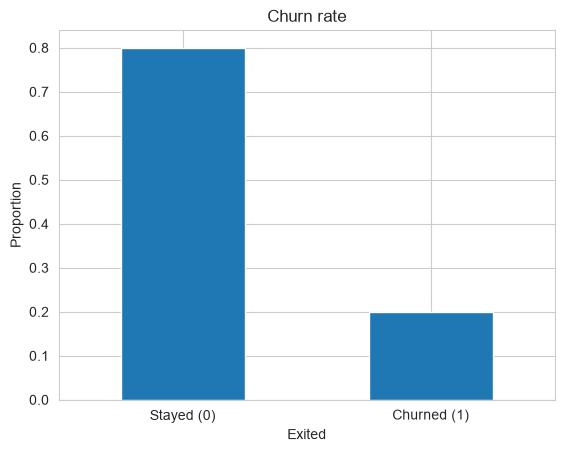

In [61]:
df["Exited"].value_counts(normalize=True).plot(kind="bar")
plt.title("Churn rate")
plt.ylabel("Proportion")
plt.xticks([0, 1], ["Stayed (0)", "Churned (1)"], rotation=0)
plt.show()

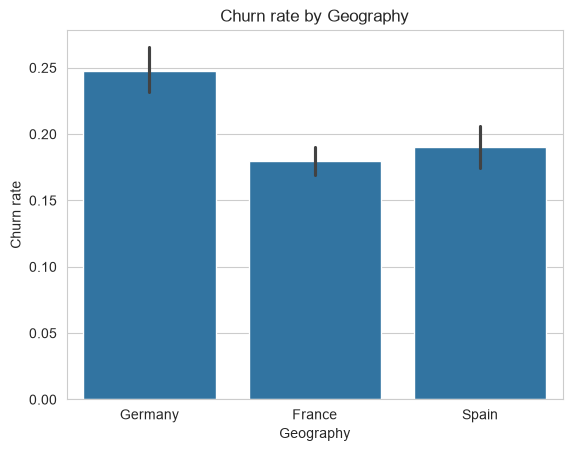

In [62]:
sns.barplot(data=df, x="Geography", y="Exited")
plt.title("Churn rate by Geography")
plt.ylabel("Churn rate")
plt.show()

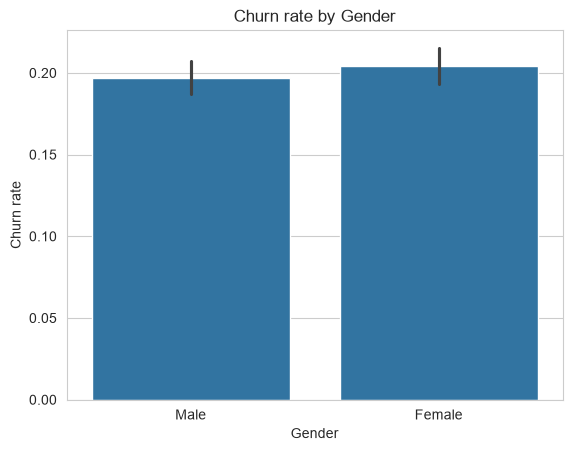

In [63]:
sns.barplot(data=df, x="Gender", y="Exited")
plt.title("Churn rate by Gender")
plt.ylabel("Churn rate")
plt.show()

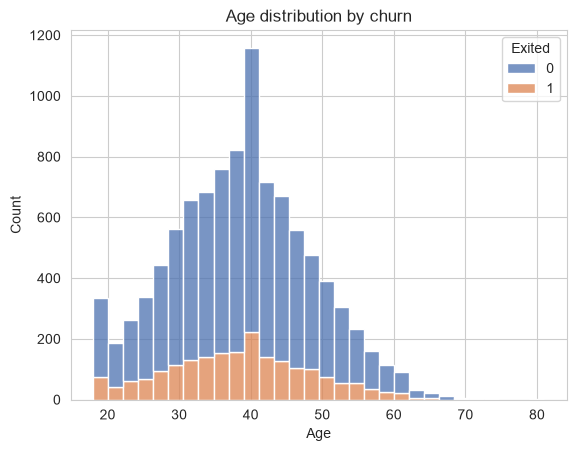

In [64]:
sns.histplot(data=df, x="Age", hue="Exited", bins=30,
             multiple="stack", palette=["#4c72b0", "#dd8452"])
plt.title("Age distribution by churn")
plt.show()

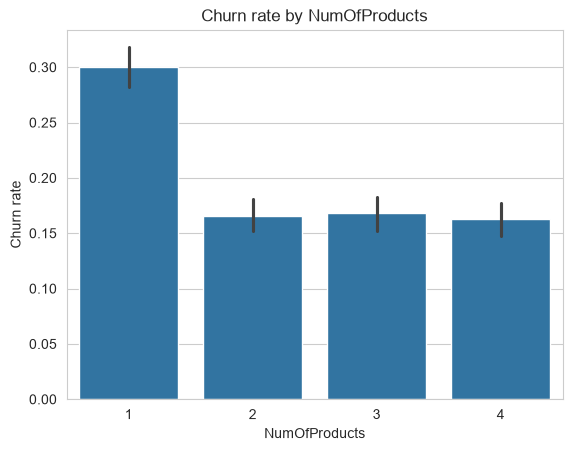

In [65]:
sns.barplot(data=df, x="NumOfProducts", y="Exited")
plt.title("Churn rate by NumOfProducts")
plt.ylabel("Churn rate")
plt.show()

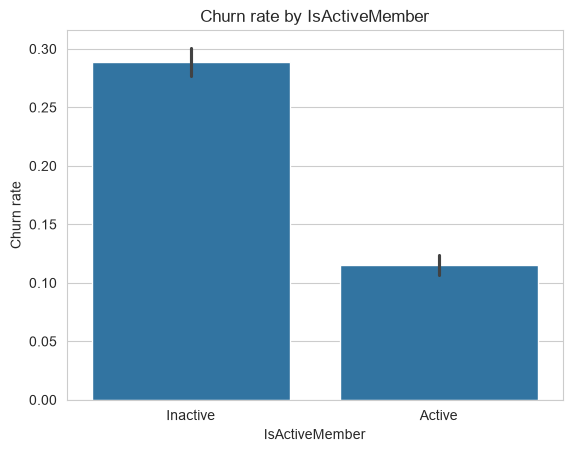

In [66]:
sns.barplot(data=df, x="IsActiveMember", y="Exited")
plt.title("Churn rate by IsActiveMember")
plt.ylabel("Churn rate")
plt.xticks([0, 1], ["Inactive", "Active"])
plt.show()

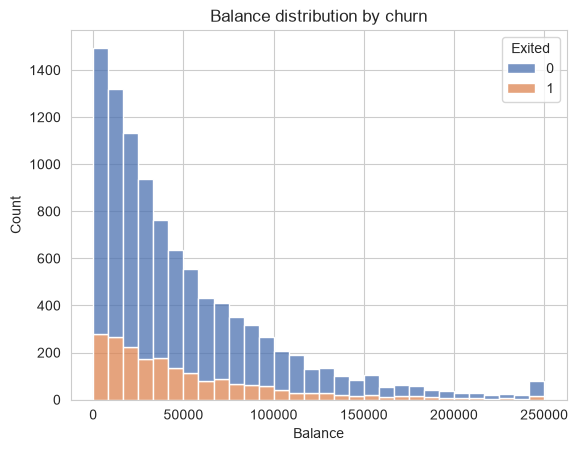

In [67]:
sns.histplot(data=df, x="Balance", hue="Exited", bins=30,
             multiple="stack", palette=["#4c72b0", "#dd8452"])
plt.title("Balance distribution by churn")
plt.show()

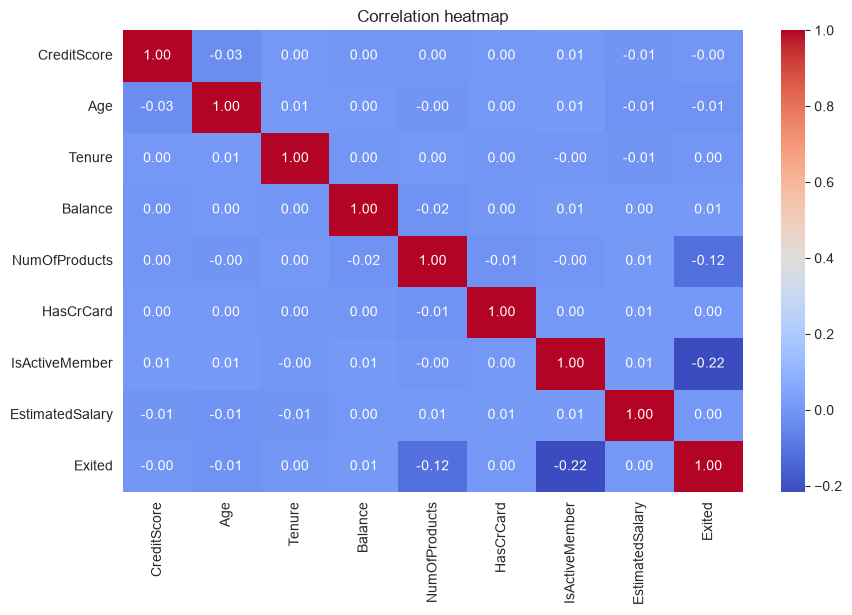

In [68]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

In [69]:
X = df.drop(columns=["Exited"])
y = df["Exited"]
print("X:", X.shape)
print("y:", y.shape)

X: (10000, 10)
y: (10000,)


In [70]:
X = pd.get_dummies(X, columns=["Geography", "Gender"], drop_first=True)
print(X.shape)
X.head()

(10000, 11)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,535,36,8,12522.885770,4,1,0,111873.839057,True,False,True
1,675,23,1,34322.606949,4,0,0,107262.028986,False,False,False
2,786,23,3,66067.728832,3,1,1,57198.191603,True,False,True
3,550,24,1,53487.653000,1,1,1,171176.739594,True,False,True
4,443,28,10,186352.011726,1,1,0,161370.802782,True,False,True


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("train:", X_train.shape, "test:", X_test.shape)
print("churn rate train:", y_train.mean().round(3))
print("churn rate test:", y_test.mean().round(3))

train: (8000, 11) test: (2000, 11)
churn rate train: 0.2
churn rate test: 0.2


In [72]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [73]:
# Preprocessing #

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))

Logistic Regression
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1600
           1       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

ROC-AUC: 0.6811


In [75]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))

Random Forest
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1600
           1       0.22      0.02      0.04       400

    accuracy                           0.79      2000
   macro avg       0.51      0.50      0.46      2000
weighted avg       0.68      0.79      0.71      2000

ROC-AUC: 0.6485


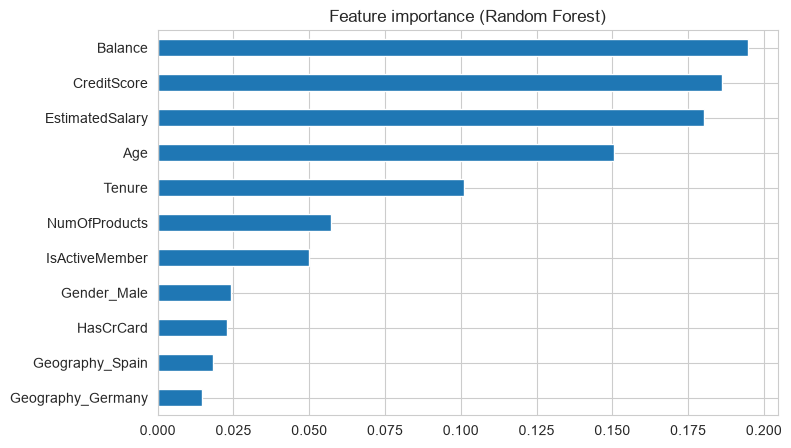

In [76]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Feature importance (Random Forest)")
plt.show()

In [77]:
print("Model                 ROC-AUC")
print("-" * 30)
print("Logistic Regression  ", round(roc_auc_score(y_test, y_proba_lr), 4))
print("Random Forest        ", round(roc_auc_score(y_test, y_proba_rf), 4))

Model                 ROC-AUC
------------------------------
Logistic Regression   0.6811
Random Forest         0.6485


In [78]:
# Modeling #

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))

Logistic Regression
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1600
           1       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

ROC-AUC: 0.6811


In [80]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))

Random Forest
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1600
           1       0.22      0.02      0.04       400

    accuracy                           0.79      2000
   macro avg       0.51      0.50      0.46      2000
weighted avg       0.68      0.79      0.71      2000

ROC-AUC: 0.6485


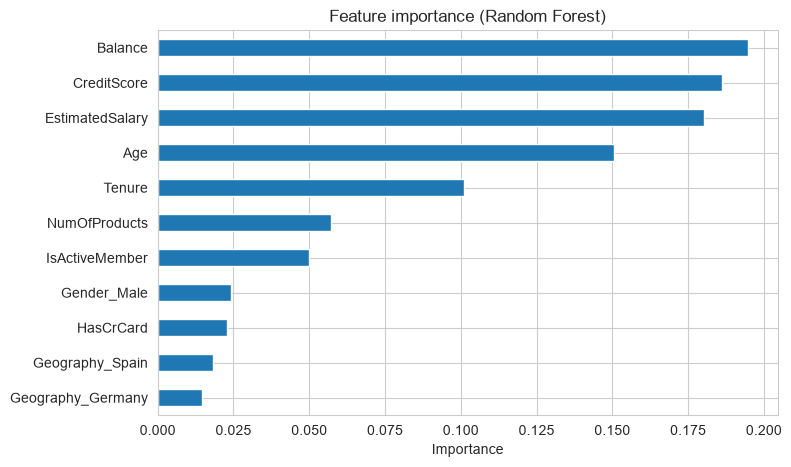

Balance              0.1948
CreditScore          0.1861
EstimatedSalary      0.1803
Age                  0.1506
Tenure               0.1011
NumOfProducts        0.0572
IsActiveMember       0.0500
Gender_Male          0.0243
HasCrCard            0.0229
Geography_Spain      0.0181
Geography_Germany    0.0147
dtype: float64


In [81]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values()
importances.plot(kind="barh", figsize=(8, 5))
plt.title("Feature importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

print(importances.sort_values(ascending=False).round(4))

In [82]:
from sklearn.metrics import roc_auc_score

print("Model                 ROC-AUC")
print("-" * 30)
print("Logistic Regression  ", round(roc_auc_score(y_test, y_proba_lr), 4))
print("Random Forest        ", round(roc_auc_score(y_test, y_proba_rf), 4))

Model                 ROC-AUC
------------------------------
Logistic Regression   0.6811
Random Forest         0.6485


In [83]:
# Model comparison #

In [84]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

print("Model                 ROC-AUC   Precision  Recall   F1")
print("-" * 60)

for name, y_pred, y_proba in [
    ("Logistic Regression", y_pred_lr, y_proba_lr),
    ("Random Forest      ", y_pred_rf, y_proba_rf),
]:
    print(
        name,
        round(roc_auc_score(y_test, y_proba), 3),
        "     ",
        round(precision_score(y_test, y_pred), 3),
        "    ",
        round(recall_score(y_test, y_pred), 3),
        "   ",
        round(f1_score(y_test, y_pred), 3),
    )

Model                 ROC-AUC   Precision  Recall   F1
------------------------------------------------------------
Logistic Regression 0.681       0.0      0.0     0.0
Random Forest       0.649       0.216      0.02     0.037


In [85]:
# Feature importance #

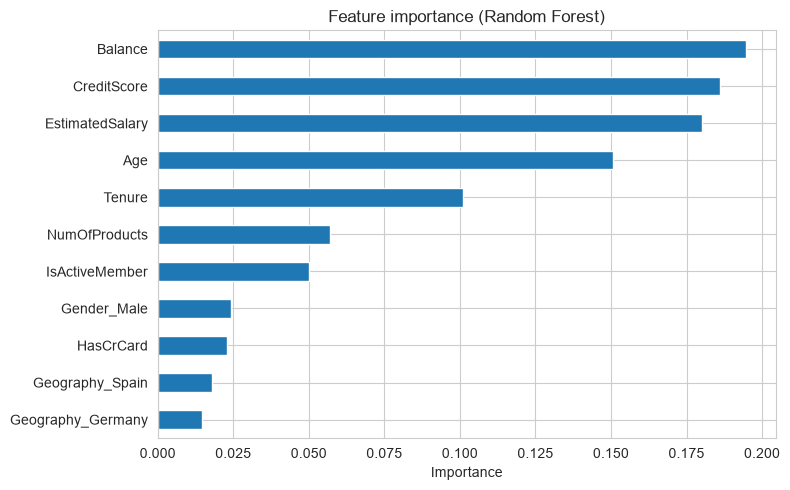

Balance              0.1948
CreditScore          0.1861
EstimatedSalary      0.1803
Age                  0.1506
Tenure               0.1011
NumOfProducts        0.0572
IsActiveMember       0.0500
Gender_Male          0.0243
HasCrCard            0.0229
Geography_Spain      0.0181
Geography_Germany    0.0147
dtype: float64


In [86]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values()

importances.plot(kind="barh", figsize=(8, 5))
plt.title("Feature importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).round(4))

In [87]:
# Refit on the full dataset and save #

In [88]:
import joblib
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_model.fit(X, y)                         # X, y = all 10,000 rows

joblib.dump(final_model, "churn_model.pkl")
joblib.dump(list(X.columns), "model_columns.pkl")

print("saved: churn_model.pkl, model_columns.pkl")
print("columns:", list(X.columns))

saved: churn_model.pkl, model_columns.pkl
columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [89]:
log_reg_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg_bal.fit(X_train, y_train)

y_pred_lr_bal = log_reg_bal.predict(X_test)
y_proba_lr_bal = log_reg_bal.predict_proba(X_test)[:, 1]

print("Logistic Regression (balanced)")
print(classification_report(y_test, y_pred_lr_bal))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr_bal), 4))
print("count > 0.5:", (y_proba_lr_bal > 0.5).sum())

Logistic Regression (balanced)
              precision    recall  f1-score   support

           0       0.87      0.63      0.73      1600
           1       0.30      0.62      0.40       400

    accuracy                           0.63      2000
   macro avg       0.58      0.63      0.57      2000
weighted avg       0.75      0.63      0.66      2000

ROC-AUC: 0.6771
count > 0.5: 841


e:\downloads\miniconda\envs\churn\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [90]:
rf_bal = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_bal.fit(X_train, y_train)

y_pred_rf_bal = rf_bal.predict(X_test)
y_proba_rf_bal = rf_bal.predict_proba(X_test)[:, 1]

print("Random Forest (balanced)")
print(classification_report(y_test, y_pred_rf_bal))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf_bal), 4))
print("count > 0.5:", (y_proba_rf_bal > 0.5).sum())

Random Forest (balanced)
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1600
           1       0.30      0.22      0.25       400

    accuracy                           0.74      2000
   macro avg       0.56      0.55      0.55      2000
weighted avg       0.71      0.74      0.73      2000

ROC-AUC: 0.6415
count > 0.5: 294


In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg_bal.fit(X_train_scaled, y_train)
y_pred_lr_bal = log_reg_bal.predict(X_test_scaled)
y_proba_lr_bal = log_reg_bal.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression (scaled + balanced)")
print(classification_report(y_test, y_pred_lr_bal))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr_bal), 4))
print("count > 0.5:", (y_proba_lr_bal > 0.5).sum())

Logistic Regression (scaled + balanced)
              precision    recall  f1-score   support

           0       0.87      0.63      0.73      1600
           1       0.30      0.63      0.41       400

    accuracy                           0.63      2000
   macro avg       0.59      0.63      0.57      2000
weighted avg       0.76      0.63      0.67      2000

ROC-AUC: 0.6811
count > 0.5: 841


In [92]:
rf_bal = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_bal.fit(X_train, y_train)

y_pred_rf_bal = rf_bal.predict(X_test)
y_proba_rf_bal = rf_bal.predict_proba(X_test)[:, 1]

print("Random Forest (balanced)")
print(classification_report(y_test, y_pred_rf_bal))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf_bal), 4))
print("count > 0.5:", (y_proba_rf_bal > 0.5).sum())

Random Forest (balanced)
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1600
           1       0.30      0.22      0.25       400

    accuracy                           0.74      2000
   macro avg       0.56      0.55      0.55      2000
weighted avg       0.71      0.74      0.73      2000

ROC-AUC: 0.6415
count > 0.5: 294


In [93]:
# Balanced Logistic Regression
log_reg_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg_bal.fit(X_train, y_train)
y_pred_lr_bal = log_reg_bal.predict(X_test)
y_proba_lr_bal = log_reg_bal.predict_proba(X_test)[:, 1]
print("Logistic Regression (balanced)")
print(classification_report(y_test, y_pred_lr_bal))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr_bal), 4))
print("count > 0.5:", (y_proba_lr_bal > 0.5).sum())

Logistic Regression (balanced)
              precision    recall  f1-score   support

           0       0.87      0.63      0.73      1600
           1       0.30      0.62      0.40       400

    accuracy                           0.63      2000
   macro avg       0.58      0.63      0.57      2000
weighted avg       0.75      0.63      0.66      2000

ROC-AUC: 0.6771
count > 0.5: 841


e:\downloads\miniconda\envs\churn\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [94]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced")),
])
final_model.fit(X, y)                       # X, y = full 10,000 rows

joblib.dump(final_model, "churn_model.pkl")
joblib.dump(list(X.columns), "model_columns.pkl")
print("saved: churn_model.pkl, model_columns.pkl")
print("columns:", list(X.columns))

saved: churn_model.pkl, model_columns.pkl
columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
